Source: https://github.com/AntoineGrimaldi/wassa/blob/main/2025-01-14_results_synthetic_data/2024-12-02_evolution_num_samples_static.ipynb
(Checked on Wed, Jan 29th)

In [1]:
#!pip install git+https://github.com/AntoineGrimaldi/wassa.git

In [2]:
!pip install git+https://github.com/bsotomayorg/wassa.git

  Cloning https://github.com/bsotomayorg/wassa.git to /tmp/pip-req-build-db26b2k_
  Running command git clone --filter=blob:none --quiet https://github.com/bsotomayorg/wassa.git /tmp/pip-req-build-db26b2k_
  Resolved https://github.com/bsotomayorg/wassa.git to commit d14cc5aa33ac9c5acc3ca46c1d762ba8f4a55e65
  Preparing metadata (setup.py) ... done
  Created wheel for wassa: filename=wassa-1.0-py3-none-any.whl size=26183 sha256=2f50100feec4c02479123e7b3fd6dbd3c6d513fe5c54914439aa18d86b131974
  Stored in directory: /tmp/pip-ephem-wheel-cache-cz86q9xm/wheels/16/cf/65/260fa20e02453e9cb2b04dd56b46dd42165e6298bb1593b3b7
Successfully built wassa


In [3]:
import torch, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from wassa.dataset_generation import sm_generative_model, generate_dataset
from wassa.wassa_plots import plot_results_std, plot_SM, plot_colored_raster
from wassa.wassa_metrics import WassDist, correlation_latent_variables, correlation_kernels, kernels_diff, torch_cdf_loss
from wassa.wassa_utils import performance_as_a_function_of_number_of_epochs

from sklearn.model_selection import train_test_split

In [4]:
! wget https://github.com/bsotomayorg/Intro_HPC_Python/raw/refs/heads/main/datasets/AllenData/ii_spike_times.npy
! wget https://github.com/bsotomayorg/Intro_HPC_Python/raw/refs/heads/main/datasets/AllenData/spike_times.npy
! wget https://github.com/bsotomayorg/Intro_HPC_Python/raw/refs/heads/main/datasets/AllenData/stim_label.npy

--2025-02-18 11:48:36--  https://github.com/bsotomayorg/Intro_HPC_Python/raw/refs/heads/main/datasets/AllenData/ii_spike_times.npy
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/bsotomayorg/Intro_HPC_Python/refs/heads/main/datasets/AllenData/ii_spike_times.npy [following]
--2025-02-18 11:48:36--  https://raw.githubusercontent.com/bsotomayorg/Intro_HPC_Python/refs/heads/main/datasets/AllenData/ii_spike_times.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3200128 (3.1M) [application/octet-stream]
Saving to: ‘ii_spike_times.npy’

ii_spike_times.npy  100%[===================>]   3.05M  --.-KB/

---

Data loading and formatting

In [5]:
spike_times    = np.load("spike_times.npy")
ii_spike_times = np.load("ii_spike_times.npy")
stim_label     = np.load("stim_label.npy")

In [6]:
np.min(spike_times), np.max(spike_times)

(1.556491042720154e-07, 0.09999947704864098)

In [7]:
def get_binned_raster(spike_times, ii_spike_times, T, nbins=100):
  # it assumes spike times are defined in [0, T]
  # T: window lenght (in seconds)
  M = ii_spike_times.shape[0]
  N = ii_spike_times.shape[1]
  mat = np.zeros(shape=(M, N, nbins), dtype=float)
  for i_M in range(M):
    for i_N in range(N):
      st = spike_times[ii_spike_times[i_M,i_N,0]:ii_spike_times[i_M,i_N,1]].copy()
      st = st*(nbins/T)
      mat[i_M, i_N, st.astype(int)] += 1
      #mat[i_M, i_N, st.astype(int)] |= True
  return mat

In [8]:
%%time
raster_tensor = get_binned_raster(spike_times, ii_spike_times[:, :100,:], T=0.100, nbins=50)

CPU times: user 243 ms, sys: 13 ms, total: 256 ms
Wall time: 341 ms


In [9]:
raster_tensor.shape # (num trials, num neurons, timesteps)

(200, 100, 50)

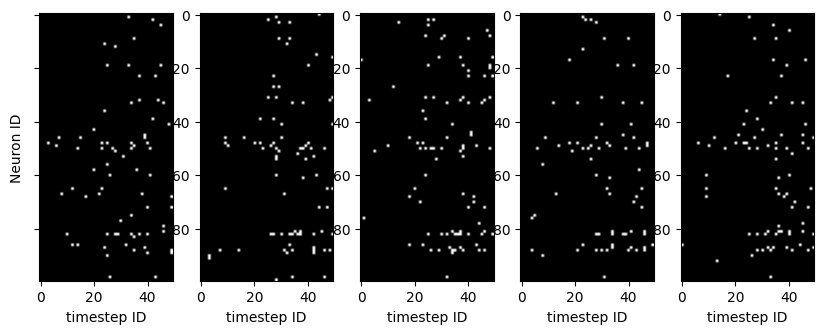

In [10]:
# example of one raster
fig, axs = plt.subplots(figsize=(10,8), facecolor='w', ncols=5)

for i in range(5):
  axs[i].imshow(raster_tensor[i], cmap='Grays_r')
  axs[i].set_xlabel("timestep ID");
  if i==0:
    axs[0].set_ylabel("Neuron ID")
  else:
    axs[0].set_yticklabels([])

In [11]:
raster_tensor.shape # num trials, num neurons, num timesteps

(200, 100, 50)

In [12]:
from wassa.wassa_metrics import WassDist, torch_cdf_loss, correlation_latent_variables, correlation_kernels, kernels_diff, get_similarity

In [13]:
from wassa.wassa_utils import cross_correlation_comp, kernels_orthogonality, smoothing, orthogonality

In [14]:
def learn_offline(criterion, model, input_raster_plot, training_parameters, path, verbose=True, device='cpu'):
    LOSS = []
    FACTORS = []
    RECONSTRUCTIONS = []
    if os.path.isfile(path + '.pth'):
        if verbose: print(path)
        model.load_state_dict(torch.load(path + '.pth', map_location=torch.device(device)))
        LOSS = torch.load(path + '_loss.pth')
        model.decoding_weights.to(device)
    else:
        model = model.to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=training_parameters.learning_rate, betas=(0.9, 0.999))

        if training_parameters.batch_size:
            nb_batch = torch.div(input_raster_plot.shape[0],training_parameters.batch_size,rounding_mode='floor')
            if nb_batch*training_parameters.batch_size!=input_raster_plot.shape[0]: nb_batch+=1
        else:
            nb_batch = 1

        for i_step in (tqdm(range(training_parameters.N_learnsteps)) if verbose else range(training_parameters.N_learnsteps)):

            # shuffle sample indices
            idx = torch.randperm(input_raster_plot.size(0))
            input_raster_plot = input_raster_plot[idx]

            for n in range(nb_batch):
                if training_parameters.batch_size:
                    X = input_raster_plot[n*training_parameters.batch_size:min((n+1)*training_parameters.batch_size,input_raster_plot.shape[0])]
                else:
                    X = input_raster_plot

                # normalization removed (RuntimeError: result type Float can't be cast to the desired output type Bool)
                #X.div_(X.sum(dim=-1, keepdim=True))
                optimizer.zero_grad()

                factors, reconstruction = model(X)
                reconstruction = reconstruction.div(reconstruction.sum(dim=-1, keepdim=True))
                loss = criterion(reconstruction, X)

                if training_parameters.lambda_ != 0:
                    if training_parameters.penalty_type == 'cc':
                        loss += training_parameters.lambda_*cross_correlation_comp(factors, mode = 'mean')
                    elif training_parameters.penalty_type == 'max_cc':
                        loss += training_parameters.lambda_*cross_correlation_comp(factors, mode = 'max')
                    elif training_parameters.penalty_type == 'smoothed_orthogonality':
                        smoothed_factors = smoothing(factors,training_parameters.smoothwind)
                        loss += training_parameters.lambda_*orthogonality(smoothed_factors)
                    #elif training_parameters.penalty_type  == 'kernels_orthogonality':
                    #    loss += training_parameters.lambda_*kernels_orthogonality(model.decoding_weights)
                    #elif training_parameters.penalty_type  == 'sparsity':
                    #    loss += training_parameters.lambda_*model.decoding_weights.abs().mean()

                LOSS.append(loss.clone().detach().cpu().numpy())
                FACTORS.append(factors.clone().detach().cpu().numpy())
                RECONSTRUCTIONS.append(reconstruction.clone().detach().cpu().numpy())
                loss.backward()
                optimizer.step()

                with torch.no_grad():
                    model.decoding_weights.data.clamp_(min=0)
                    model.decoding_weights.data.div_((torch.linalg.norm(model.decoding_weights.data, ord=2, dim=(1,2), keepdim=True)).repeat(1,model.decoding_weights.shape[1],model.decoding_weights.shape[2]))

        torch.save(model.state_dict(), path + '.pth')
        torch.save(LOSS, path + '_loss.pth')

    return {'model': model, 'loss': LOSS, 'factors':FACTORS, 'reconstructions':RECONSTRUCTIONS}


In [15]:
from wassa import WassA

def write_path(dir, date, training_params, iteration=0):
    # modified
    return f'{dir}{date}_{training_params.get_parameters()}_{iteration}'

def train_allendata(trainset_input, testset_input, testset_output, training_parameters, date, results_directory = '../results/', iteration = 0, plot = False, order_sms=True, verbose = False, device = 'cpu'):
    sm_opt = {}
    if not os.path.exists(results_directory):
        os.mkdir(results_directory)

    autoencoder = WassA(
        training_parameters[0].kernel_size,
        weight_init = training_parameters[0].weight_init,
        output=training_parameters[0].output,
        do_bias=training_parameters[0].do_bias,
        device=device)

    loss_evolution = []
    for params in training_parameters:
        if params.loss_type == 'mse':
            loss = torch.nn.MSELoss()
        else:
            loss = WassDist(p=params.wass_order, zeros=params.zeros)
        if len(training_parameters)==2:
            path = "." #write_path(results_directory, date+'_combined', params, iteration=iteration)
            learnsteps_init = params.N_learnsteps
            params.N_learnsteps = learnsteps_init//2
        else:
            path = "." #write_path(results_directory, date, params, iteration=iteration)
        results = learn_offline(loss, autoencoder, trainset_input, params, path, verbose=verbose, device = device)
        autoencoder, loss_over_epochs = results['model'], results['loss']
        loss_evolution.append(loss_over_epochs)

        if len(training_parameters)==2: params.N_learnsteps = learnsteps_init

    return loss_evolution[-1], results


---

In [16]:
raster_tensor.shape

(200, 100, 50)

---
WassA

In [17]:
date = '2024-02-18'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [18]:
class training_parameters:
    # (trials or different classes?, number of neurons, timesteps)
    kernel_size = raster_tensor.shape #(sm.opt.N_SMs, sm.opt.N_pre, sm.opt.N_delays)
    loss_type = 'mse'
    N_learnsteps = 1000
    learning_rate = 0.001
    penalty_type = None
    smoothwind = 20
    lambda_ = .1
    batch_size = None
    output = 'linear'
    do_bias = True
    zeros = 'ignore'
    wass_order = 1
    weight_init = None
    if not penalty_type:
        lambda_ = 0
    elif penalty_type[:8] != 'smoothed':
        smoothwind = 0
    if lambda_ == 0:
        penalty_type = None
    def get_parameters(self):
        name = f'{self.loss_type}_{self.output}_{self.penalty_type}_{self.do_bias}_{self.kernel_size}_{self.N_learnsteps}_{self.learning_rate}_{self.lambda_}_{self.batch_size}_{self.smoothwind}'
        if self.loss_type == 'emd':
            name += f'_{self.zeros}_{self.wass_order}'
        return name

---
Training. Definition of datasets

In [19]:
params_mse = training_parameters()
params_emd = training_parameters()
params_emd.loss_type = 'emd'

In [20]:
X_train, X_test, y_train, y_test = train_test_split(raster_tensor, stim_label, test_size=0.4, random_state=0)

In [21]:
X_train.shape, y_train.shape, np.unique(y_train, return_counts=True)

((120, 100, 50),
 (120,),
 (array([  0,  45,  90, 135]), array([31, 30, 27, 32])))

from numpy to torch

In [22]:
trainset_input = torch.tensor(X_train, dtype=torch.float32).to(device)
testset_input  = torch.tensor(X_test, dtype=torch.float32).to(device)
testset_output = torch.tensor(y_test, dtype=torch.float32).to(device)

In [23]:
trainset_input.device, testset_input.device, testset_output.device

(device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cuda', index=0))

In [28]:
%%time
loss, results = train_allendata(
    trainset_input, testset_input, testset_output, [training_parameters], date,
    results_directory = 'results/', iteration = 0, device = device)


CPU times: user 17.7 ms, sys: 3 ms, total: 20.7 ms
Wall time: 23.3 ms


<ipython-input-14-12a244fa80a9>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path + '.pth', map_location=torch.device(device)))
<ipython

In [29]:
results.keys()

dict_keys(['model', 'loss', 'factors', 'reconstructions'])

---
**Ask Antoine:** this loss looks strange...

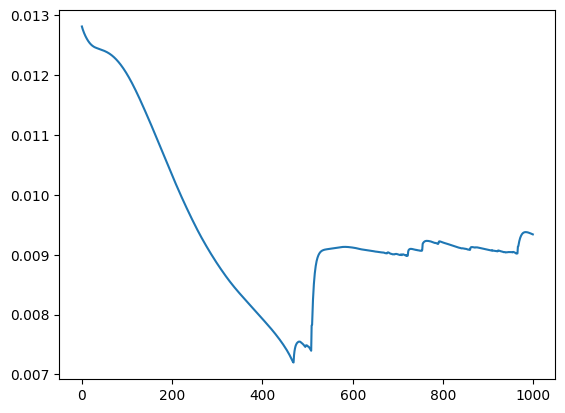

In [30]:
plt.plot(loss)

In [31]:
results['factors'] # why empty?

[]

In [32]:
results['reconstructions']

[]

In [33]:
trainset_input.shape

torch.Size([120, 100, 50])

In [34]:
testset_input.shape

torch.Size([80, 100, 50])

In [35]:
testset_output.shape

torch.Size([80])

In [36]:
# these values correspond to the orientation value of drifting gratings stimuli
testset_output

tensor([  0., 135.,  90.,  45., 135., 135.,   0.,  90.,   0., 135.,  45.,  90.,
        135., 135.,  45.,   0.,   0.,  90.,   0.,  45., 135.,  90.,   0., 135.,
         45.,  90., 135., 135.,  90.,   0.,   0.,  45., 135.,  90.,   0., 135.,
         90.,   0.,  45.,  90.,  90.,  45.,   0.,  90., 135.,  45.,   0.,  45.,
         90.,  90.,  45.,  90., 135.,  45.,  90.,   0.,   0., 135.,   0.,  45.,
         90.,  45., 135.,   0., 135.,  45.,  45., 135.,  45.,  45.,  90.,  45.,
         90.,  90.,  90.,  45.,  90.,   0.,   0.,  90.], device='cuda:0')